In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/sp-500-stocks")

print("Path to dataset files:", path)

/home/manish/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/manish/.cache/kagglehub/datasets/andrewmvd/sp-500-stocks/versions/1023


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.cm as cm
from sklearn.model_selection import train_test_split
from statsmodels.tsa.deterministic import DeterministicProcess
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(f"{path}/sp500_index.csv", parse_dates = ["Date"])
df = df.rename(columns={"S&P500": "Price"})
df = df.set_index("Date")
df = df.to_period("D")
df.head(5)

,Price
Date,
2014-12-22,2078.54
2014-12-23,2082.17
2014-12-24,2081.88
2014-12-26,2088.77
2014-12-29,2090.57


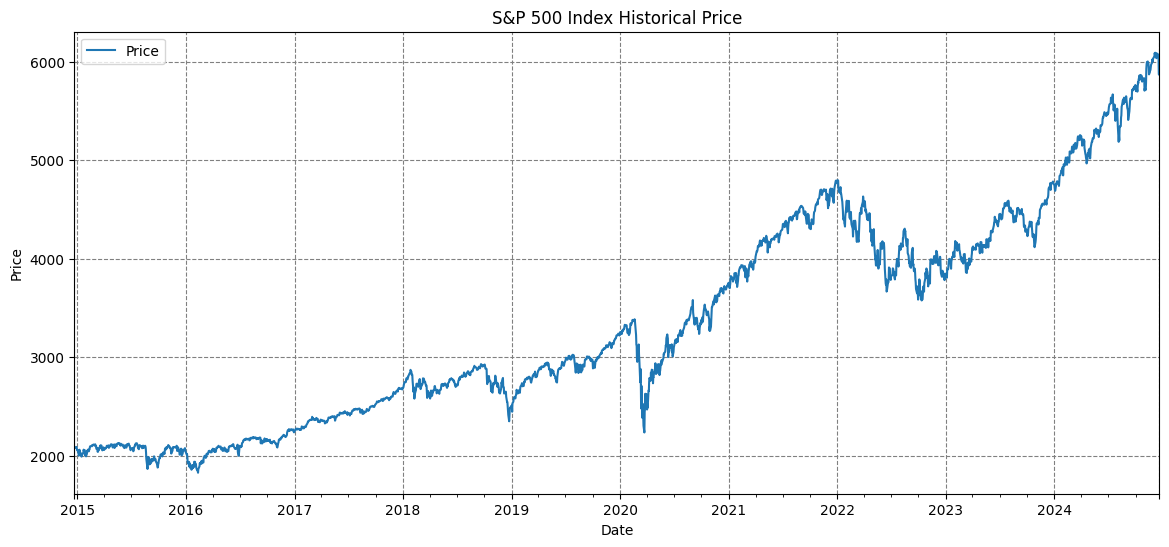

In [4]:
df["Price"].plot(figsize=(14, 6))
plt.title("S&P 500 Index Historical Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(color="gray", linestyle="--")
plt.show()

## Adding deterministic process
this will essentially be the constant and trend features that will be used for future models

In [5]:
dp = DeterministicProcess(
    index=df.index,
    constant=True,
    order=1,
    drop=True,
)

X = dp.in_sample()

X.head()

,const,trend
Date,,
2014-12-22,1.0,1.0
2014-12-23,1.0,2.0
2014-12-24,1.0,3.0
2014-12-26,1.0,4.0
2014-12-29,1.0,5.0


## This is moving average

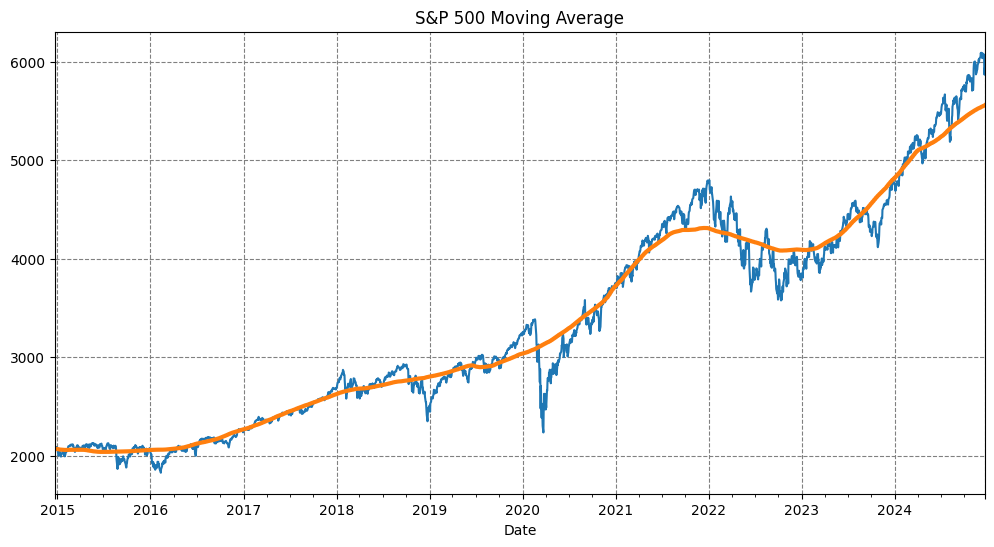

In [6]:
moving_average = df.rolling(
    window=365,
    center=True,
    min_periods=183,
).mean()



ax = df["Price"].plot(title="S&P 500 Moving Average")
ax = moving_average.plot(ax=ax, label="Moving Average", linewidth=3, figsize=(12, 6), legend=False)
plt.grid(color="gray", linestyle="--")

In [7]:
y = df.loc[:, "Price"]

model = LinearRegression()
model.fit(X, y)

y_pred = pd.Series(model.predict(X), index=X.index)

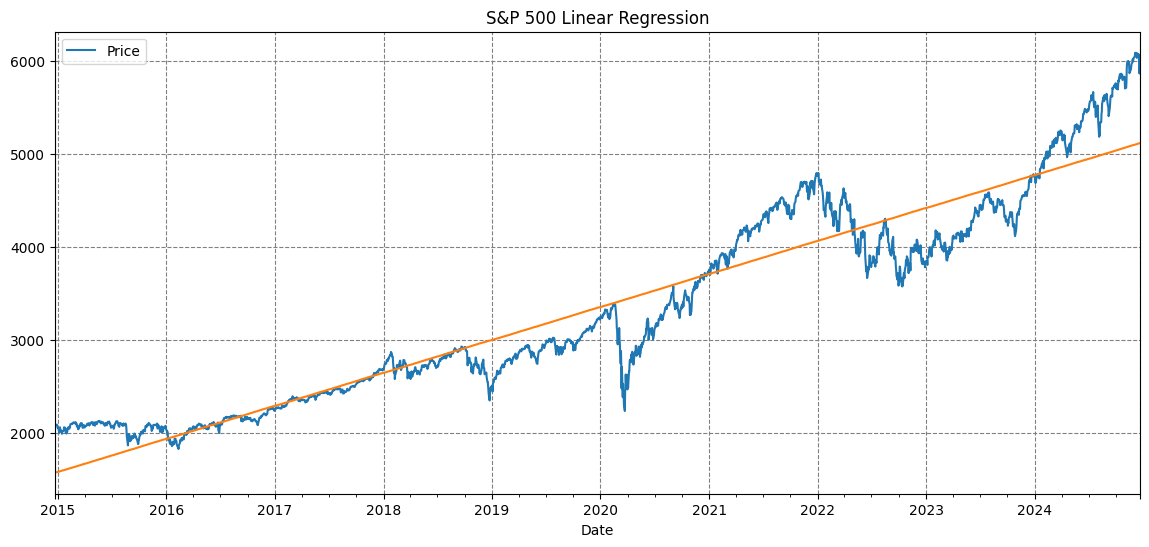

In [8]:
ax = df.plot()
_ = y_pred.plot(ax=ax, label="Trend", figsize=(14, 6), title="S&P 500 Linear Regression")
plt.grid(color="gray", linestyle="--")

The linear regression model can be utilized to make forecasts by producing deterministic trends outside of the time period that it has been trained upon. In this case, it will be extrapolated by 365 steps or an entire year.

In [9]:
X = dp.out_of_sample(steps=365)

y_fore = pd.Series(model.predict(X), index=X.index)

y_fore.head()


2024-12-21    5120.233420
2024-12-22    5121.642381
2024-12-23    5123.051341
2024-12-24    5124.460302
2024-12-25    5125.869263
Freq: D, dtype: float64

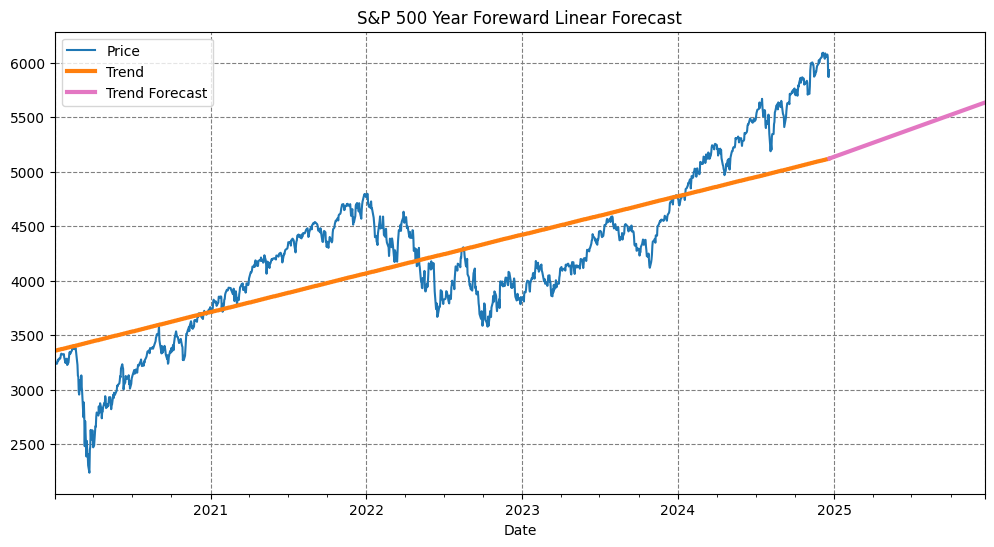

In [10]:
ax = df["2020":].plot(title="S&P 500 Year Foreward Linear Forecast")
ax = y_pred["2020":].plot(ax=ax, linewidth=3, label="Trend")
ax = y_fore.plot(ax=ax, linewidth=3, label="Trend Forecast", color="C6", figsize=(12, 6))
_ = ax.legend()
plt.grid(color="gray", linestyle="--")

## Multi Output Strategy

Lag values are values from before the current value, essentially the past value of what's presently being observed (Haden, 2025). For instance, a one-day lag feature can be a copied column in a dataset that is one day late from the original column; they can be helpful in identifying patterns and feature engineering, wherein they can add more potential insights to the already present information. They will be used here to synthesize more data for a Multi-output strategy, utilizing a model that produces multiple outputs, such as linear regression. Thirty lags would be created to be added to the dataset, which will be trained and tested by the model to forecast thirty days from each datum into the future.

In [11]:
def make_lags(ts, lags, lead_time=1):
    return pd.concat(
        {
            f"y_lag_{i}": ts.shift(i)
            for i in range(lead_time, lags + lead_time)
        },
        axis=1)


y = df["Price"]
X = make_lags(y, lags=30).fillna(0.0)


def make_multistep_target(ts, steps):
    return pd.concat(
        {f"y_step_{i + 1}": ts.shift(-i)
         for i in range(steps)},
        axis=1)

y = make_multistep_target(y, steps=30).dropna()

y, X = y.align(X, join="inner", axis=0)

## Autocorrelation

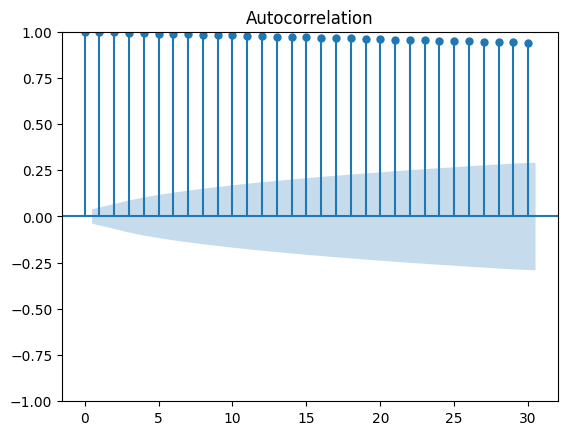

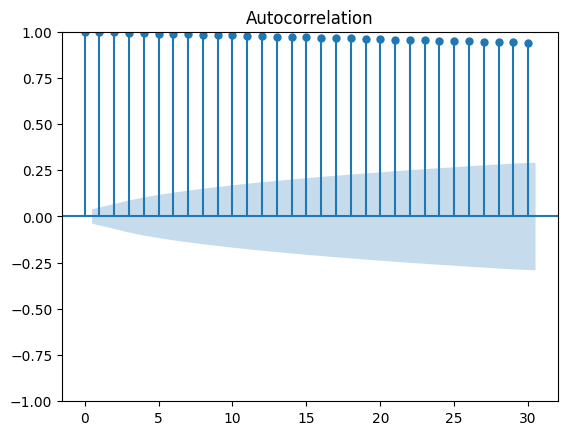

In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df['Price'], lags=30)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=False)

model = LinearRegression()
model.fit(X_train, y_train)

y_fit = pd.DataFrame(model.predict(X_train), index=X_train.index, columns=y.columns)
y_pred = pd.DataFrame(model.predict(X_test), index=X_test.index, columns=y.columns)

In [14]:
# For older versions (< 1.0), calculate RMSE manually
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate MSE first, then take sqrt for RMSE
train_mse = mean_squared_error(y_train, y_fit)
train_rmse = np.sqrt(train_mse)

test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE:  {test_rmse:.2f}")
print(f"MAE:        {mae:.2f}")
print(f"R²:         {r2:.4f}")

Train RMSE: 129.99
Test RMSE:  171.39
MAE:        137.65
R²:         0.9350


## MultiOutput Results

The evaluation comes from the test predictions and is measured in root mean squared error, how far off the predictions are; mean absolute error, the average magnitude of the errors; and the coefficient of determination, the amount of variation in the true values that is explained by the model.

The multioutput linear regression model shows strong performance with a test RMSE of 163.47, indicating a moderate average error in predictions. The MAE of 137.65 suggests that errors are fairly consistent across the predictions. The R² value of 0.9350 indicates that the model explains about 93.5% of the variance in the data.

In [15]:
def plot_multistep(y, every=1, ax=None, palette_kwargs=None):
    palette_kwargs_ = dict(palette="husl", n_colors=16, desat=None)
    if palette_kwargs is not None:
        palette_kwargs_.update(palette_kwargs)
    palette = sns.color_palette(**palette_kwargs_)
    if ax is None:
        fig, ax = plt.subplots()
    ax.set_prop_cycle(plt.cycler("color", palette))
    for date, preds in y[::every].iterrows():
        preds.index = pd.period_range(start=date, periods=len(preds))
        preds.plot(ax=ax)
    return ax

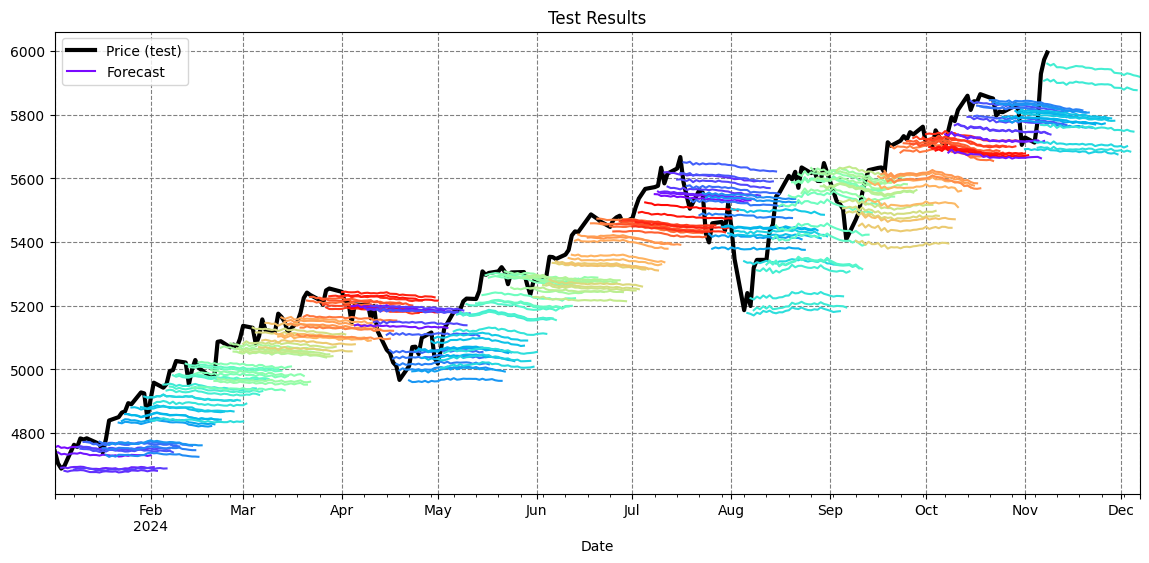

In [16]:
df_filtered = df[df.index >= "2020"]
y_pred_filtered = y_pred[y_pred.index >= "2024"]

fig, ax = plt.subplots(figsize=(14, 6))

ax = df_filtered["Price"][y_pred_filtered.index].plot(ax=ax, color="black", linewidth=3)
ax = plot_multistep(y_pred_filtered, ax=ax, palette_kwargs=dict(palette="rainbow", n_colors=64))

ax.legend(["Price (test)", "Forecast"])
ax.set_title("Test Results")
plt.grid(color="gray", linestyle="--")

plt.show()

In [17]:
import torch

def ensure_datetime(date_obj):
    if isinstance(date_obj, pd.Period):
        return date_obj.to_timestamp()
    return date_obj

if isinstance(df.index, pd.PeriodIndex):
    df.index = df.index.to_timestamp()

dates = df.index

prices = df["Price"].values.reshape(-1, 1)
scaler = MinMaxScaler()
prices_scaled = scaler.fit_transform(prices)

def create_sequences(data, dates, input_len=60, output_len=7):
    X, y = [], []
    X_dates, y_dates = [], []
    
    for i in range(len(data) - input_len - output_len):
        X.append(data[i:i+input_len])
        y.append(data[i+input_len:i+input_len+output_len])
        
        X_dates.append(dates[i+input_len])
        y_dates.append(dates[i+input_len:i+input_len+output_len])
        
    return torch.tensor(X), torch.tensor(y), X_dates, y_dates
X, y, X_dates, y_dates = create_sequences(prices_scaled, dates, input_len=60, output_len=30)

/tmp/ipykernel_25670/2715680983.py:28: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  return torch.tensor(X), torch.tensor(y), X_dates, y_dates


In [18]:
split = int(0.75 * len(X))
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

In [19]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([1820, 60, 1]) torch.Size([1820, 30, 1])
torch.Size([607, 60, 1]) torch.Size([607, 30, 1])


In [26]:
# Saving the train and test files for future useimport pickle
import pickle
# Save to pickle file
data_to_save = {
    'X_train': X_train,
    'y_train': y_train,
    'X_test': X_test,
    'y_test': y_test
}

# Save
with open('sp500_data.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)

print("Data saved to 'sp500_data.pkl'")

Data saved to 'sp500_data.pkl'


X_train dtype: torch.float32, shape: torch.Size([1820, 60, 1])
y_train dtype: torch.float32, shape: torch.Size([1820, 30, 1])
Using device: cpu
Model dtype: next(model.parameters()).dtype
X_train dtype on device: torch.float32
y_train dtype on device: torch.float32
Epoch 0: Train RMSE: 0.0823, Test RMSE: 0.1394, LR: 0.001000
Epoch 100: Train RMSE: 0.0301, Test RMSE: 0.1018, LR: 0.000500
Early stopping at epoch 115

Final Results:
Train RMSE: 0.0314
Test RMSE: 0.0638


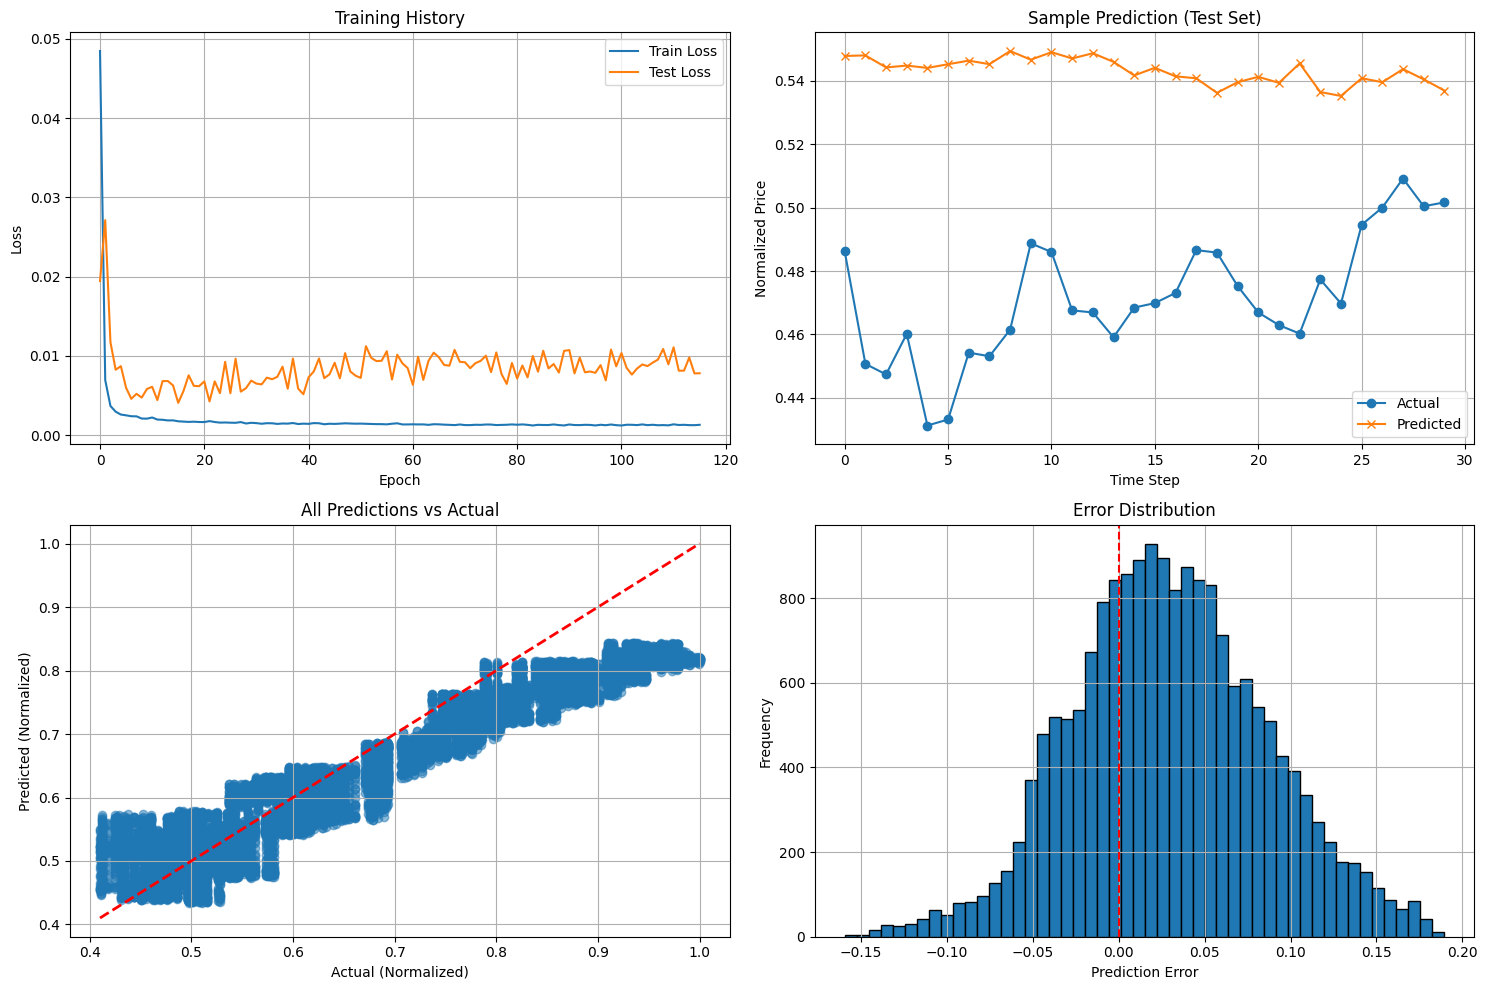

Test RMSE (Original Scale): $272.04


In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import numpy as np
import matplotlib.pyplot as plt

# FIX 1: Convert your data to float32 when creating tensors
def create_sequences(data, dates, input_len=60, output_len=7):
    X, y = [], []
    X_dates, y_dates = [], []
    
    for i in range(len(data) - input_len - output_len):
        X.append(data[i:i+input_len])
        y.append(data[i+input_len:i+input_len+output_len])
        
        X_dates.append(dates[i+input_len])
        y_dates.append(dates[i+input_len:i+input_len+output_len])
        
    # FIX: Add .float() to convert to float32
    return torch.tensor(X).float(), torch.tensor(y).float(), X_dates, y_dates

# Recreate your sequences with float32
X, y, X_dates, y_dates = create_sequences(prices_scaled, dates, input_len=60, output_len=30)

# Split the data
split = int(0.75 * len(X))
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

print(f"X_train dtype: {X_train.dtype}, shape: {X_train.shape}")
print(f"y_train dtype: {y_train.dtype}, shape: {y_train.shape}")

# Model definition (unchanged)
class SimpleLSTMModel(nn.Module):
    def __init__(self, input_len=60, output_len=30):
        super().__init__()
        self.input_len = input_len
        self.output_len = output_len
        
        # Process input sequence
        self.lstm = nn.LSTM(input_size=1, hidden_size=50, num_layers=2, batch_first=True, dropout=0.2)
        
        # Fully connected layers to produce all outputs at once
        self.fc = nn.Sequential(
            nn.Linear(50, 100),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(100, output_len)
        )
    
    def forward(self, x):
        # x shape: [batch_size, input_len, 1]
        # Process through LSTM
        lstm_out, (hidden, cell) = self.lstm(x)
        
        # Use the last hidden state to predict all future values
        last_hidden = hidden[-1]  # Take last layer's hidden state
        predictions = self.fc(last_hidden)  # [batch_size, output_len]
        
        # Reshape to match target shape
        predictions = predictions.unsqueeze(-1)  # [batch_size, output_len, 1]
        return predictions

# Create model
model = SimpleLSTMModel(input_len=60, output_len=30)

# Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# FIX 2: Ensure tensors are float32 when moving to device
model = model.to(device)
X_train = X_train.float().to(device)  # Add .float() if needed
y_train = y_train.float().to(device)
X_test = X_test.float().to(device)
y_test = y_test.float().to(device)

# Verify dtypes
print(f"Model dtype: next(model.parameters()).dtype")
print(f"X_train dtype on device: {X_train.dtype}")
print(f"y_train dtype on device: {y_train.dtype}")

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=50, factor=0.5)

# Loss function
loss_fn = nn.MSELoss()

# Data loader
loader = data.DataLoader(
    data.TensorDataset(X_train, y_train), 
    shuffle=True, 
    batch_size=32,
    drop_last=True
)

# Training loop
n_epochs = 2000
best_test_loss = float('inf')
patience = 100
patience_counter = 0

train_losses = []
test_losses = []

for epoch in range(n_epochs):
    # Training
    model.train()
    train_loss = 0
    for X_batch, y_batch in loader:
        # FIX 3: Ensure batch tensors are on correct device and dtype
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        train_loss += loss.item()
    
    avg_train_loss = train_loss / len(loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    with torch.no_grad():
        y_pred_train = model(X_train)
        train_rmse = torch.sqrt(loss_fn(y_pred_train, y_train))
        
        y_pred_test = model(X_test)
        test_loss = loss_fn(y_pred_test, y_test)
        test_rmse = torch.sqrt(test_loss)
        test_losses.append(test_loss.item())
    
    # Learning rate scheduling
    scheduler.step(test_loss)
    
    # Early stopping check
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
    
    # Print progress
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Train RMSE: {train_rmse:.4f}, Test RMSE: {test_rmse:.4f}, LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    # Early stopping
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

# Load best model
model.load_state_dict(torch.load('best_model.pth'))

# Final evaluation
model.eval()
with torch.no_grad():
    y_pred_train = model(X_train)
    y_pred_test = model(X_test)
    
    train_rmse = torch.sqrt(loss_fn(y_pred_train, y_train)).item()
    test_rmse = torch.sqrt(loss_fn(y_pred_test, y_test)).item()
    
print(f"\nFinal Results:")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

# Plot results
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot training history
axes[0, 0].plot(train_losses, label='Train Loss')
axes[0, 0].plot(test_losses, label='Test Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training History')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot predictions vs actual for a sample
sample_idx = 0
axes[0, 1].plot(y_test[sample_idx, :, 0].cpu().numpy(), label='Actual', marker='o')
axes[0, 1].plot(y_pred_test[sample_idx, :, 0].cpu().numpy(), label='Predicted', marker='x')
axes[0, 1].set_xlabel('Time Step')
axes[0, 1].set_ylabel('Normalized Price')
axes[0, 1].set_title(f'Sample Prediction (Test Set)')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Plot all test predictions vs actual
all_actual = y_test[:, :, 0].cpu().numpy().flatten()
all_pred = y_pred_test[:, :, 0].cpu().numpy().flatten()

axes[1, 0].scatter(all_actual, all_pred, alpha=0.5)
axes[1, 0].plot([all_actual.min(), all_actual.max()], 
                [all_actual.min(), all_actual.max()], 'r--', lw=2)
axes[1, 0].set_xlabel('Actual (Normalized)')
axes[1, 0].set_ylabel('Predicted (Normalized)')
axes[1, 0].set_title('All Predictions vs Actual')
axes[1, 0].grid(True)

# Plot error distribution
errors = all_actual - all_pred
axes[1, 1].hist(errors, bins=50, edgecolor='black')
axes[1, 1].axvline(x=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Prediction Error')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Error Distribution')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Inverse transform function
def inverse_transform_predictions(scaler, predictions):
    """Convert normalized predictions back to original scale"""
    pred_np = predictions.cpu().numpy()
    original_shape = pred_np.shape
    
    pred_reshaped = pred_np.reshape(-1, 1)
    pred_original = scaler.inverse_transform(pred_reshaped)
    
    return pred_original.reshape(original_shape)

# Get predictions in original scale
y_pred_test_original = inverse_transform_predictions(scaler, y_pred_test)
y_test_original = inverse_transform_predictions(scaler, y_test)

# Calculate RMSE in original scale
test_rmse_original = np.sqrt(np.mean((y_test_original - y_pred_test_original) ** 2))
print(f"Test RMSE (Original Scale): ${test_rmse_original:.2f}")

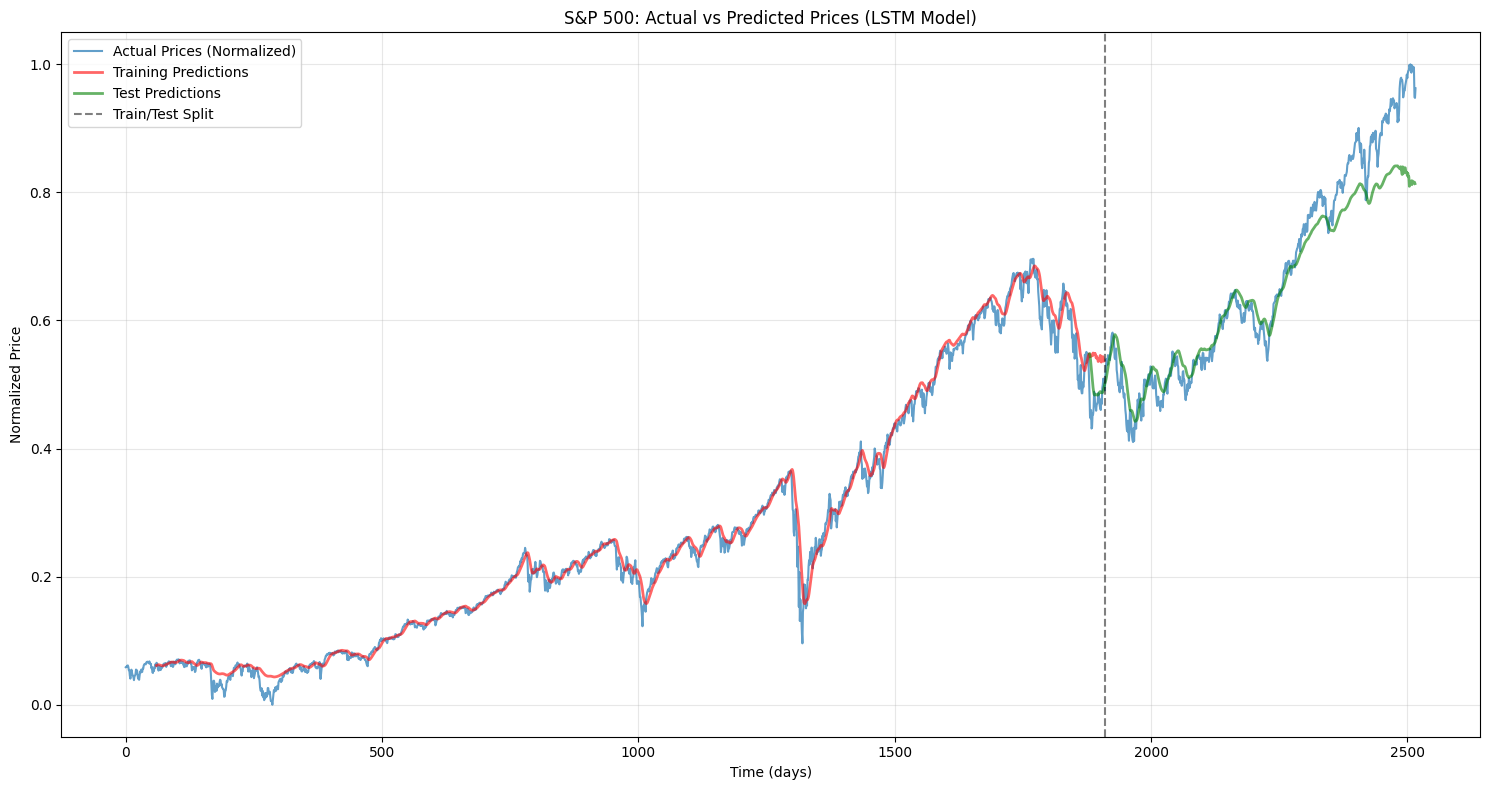

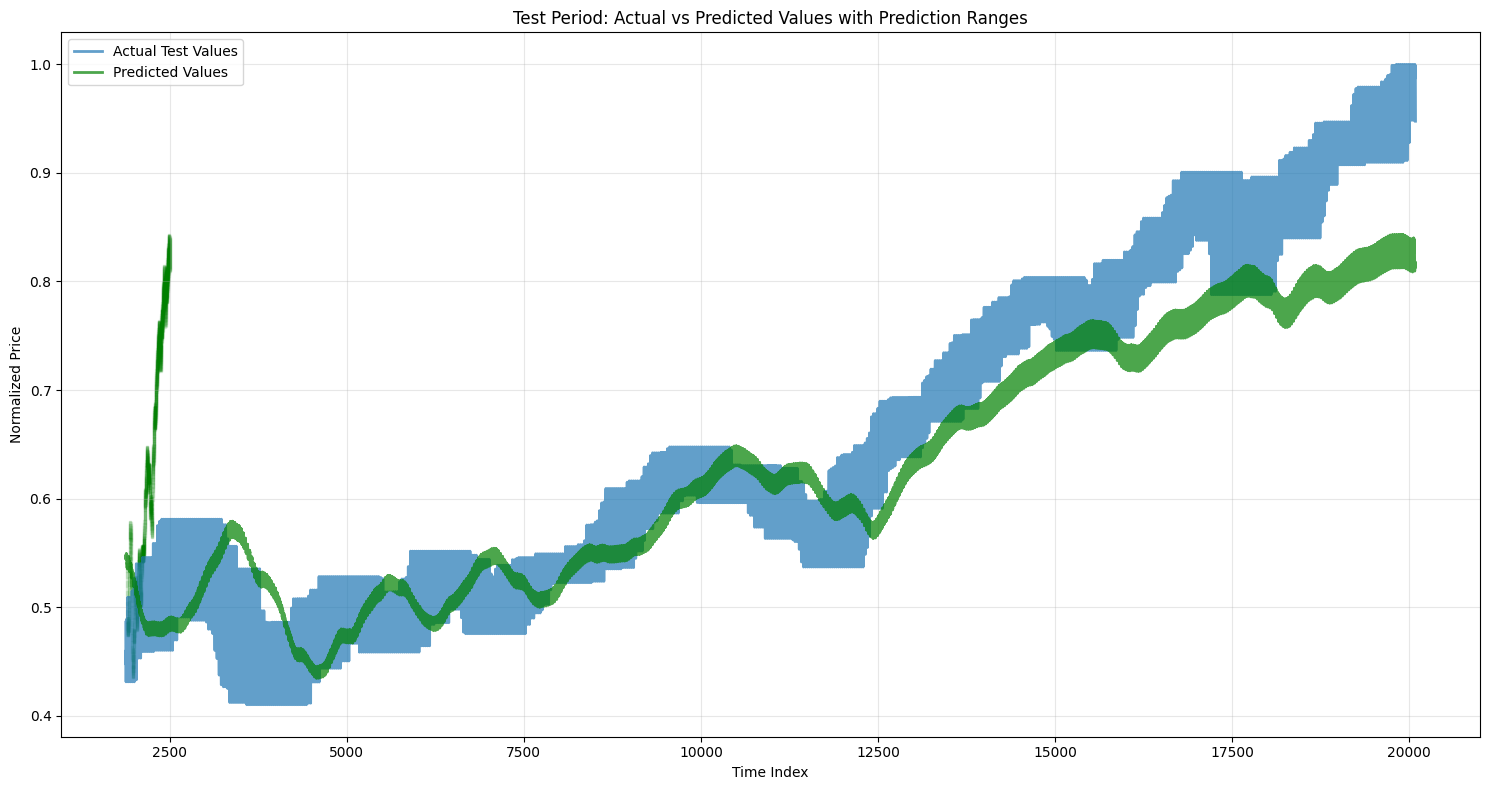

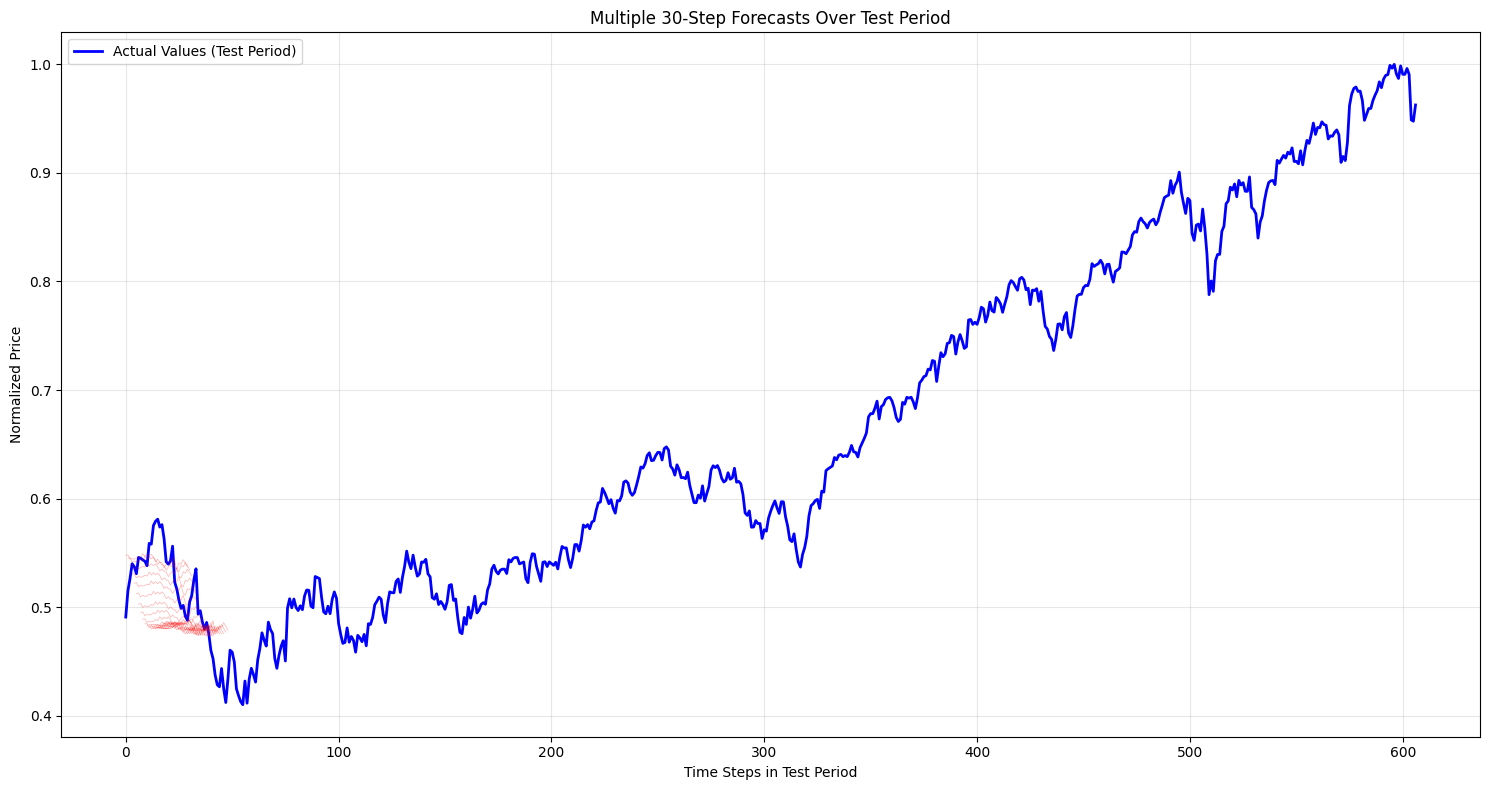


PERFORMANCE METRICS
Mean Squared Error (MSE): 0.004076
Root Mean Squared Error (RMSE): 0.063841
Mean Absolute Error (MAE): 0.050520
Mean Absolute Percentage Error (MAPE): 7.40%

In Original Price Scale:
RMSE: $272.04
MAE: $215.27
Average Price in Test Set: $4621.49
RMSE as % of Average: 5.89%


In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Set up the plot
plt.figure(figsize=(15, 8))

# Get predictions
model.eval()
with torch.no_grad():
    # Get predictions for training and test sets
    y_pred_train = model(X_train)
    y_pred_test = model(X_test)
    
    # Convert to numpy
    y_pred_train_np = y_pred_train.cpu().numpy()  # Shape: [train_samples, 30, 1]
    y_pred_test_np = y_pred_test.cpu().numpy()    # Shape: [test_samples, 30, 1]
    
    # Get actual values
    y_train_np = y_train.cpu().numpy()
    y_test_np = y_test.cpu().numpy()
    
    # Create arrays for plotting (filled with NaN initially)
    train_predictions_plot = np.ones_like(prices_scaled) * np.nan
    test_predictions_plot = np.ones_like(prices_scaled) * np.nan
    
    # Fill training predictions (predicting 30 steps ahead)
    # We need to map predictions back to their original time positions
    input_len = 60
    output_len = 30
    
    # For training predictions
    for i in range(len(X_train)):
        start_idx = i + input_len  # Where prediction starts
        end_idx = start_idx + output_len  # Where prediction ends
        
        # Only fill if within bounds
        if end_idx <= len(prices_scaled):
            # Take the prediction for this sample
            # We'll use the first predicted value for simplicity
            # Or you could use the mean of all 30 predictions
            train_predictions_plot[start_idx:end_idx] = y_pred_train_np[i]
    
    # For test predictions (they start after training split)
    train_samples = len(X_train)
    for i in range(len(X_test)):
        start_idx = train_samples + i + input_len
        end_idx = start_idx + output_len
        
        if end_idx <= len(prices_scaled):
            test_predictions_plot[start_idx:end_idx] = y_pred_test_np[i]
    
    # Plot everything
    plt.plot(prices_scaled, label='Actual Prices (Normalized)', alpha=0.7, linewidth=1.5)
    plt.plot(train_predictions_plot, label='Training Predictions', color='red', alpha=0.6, linewidth=2)
    plt.plot(test_predictions_plot, label='Test Predictions', color='green', alpha=0.6, linewidth=2)
    
    # Add vertical line separating train and test
    split_point = len(X_train) + input_len + output_len
    plt.axvline(x=split_point, color='black', linestyle='--', alpha=0.5, label='Train/Test Split')
    
    # Add labels and title
    plt.xlabel('Time (days)')
    plt.ylabel('Normalized Price')
    plt.title('S&P 500: Actual vs Predicted Prices (LSTM Model)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Show the plot
    plt.tight_layout()
    plt.show()

# Alternative: Plot just the test period predictions vs actual
plt.figure(figsize=(15, 8))

# Get the actual test values (not scaled for better interpretation)
with torch.no_grad():
    # Get test predictions
    test_predictions = model(X_test).cpu().numpy()  # Shape: [test_samples, 30, 1]
    
    # Create a time index for test period
    test_start_idx = len(X_train) + input_len
    time_index = range(test_start_idx, test_start_idx + len(test_predictions.flatten()))
    
    # Flatten predictions (all 30-step predictions concatenated)
    flat_predictions = test_predictions.flatten()
    
    # Get corresponding actual values
    actual_test_values = []
    for i in range(len(X_test)):
        start_idx = test_start_idx + i
        # Get actual values for the 30-step horizon
        if start_idx + output_len <= len(prices_scaled):
            actual_test_values.extend(prices_scaled[start_idx:start_idx+output_len].flatten())
    
    # Trim to same length
    min_length = min(len(flat_predictions), len(actual_test_values))
    flat_predictions = flat_predictions[:min_length]
    actual_test_values = np.array(actual_test_values[:min_length])
    time_index = time_index[:min_length]
    
    # Plot
    plt.plot(time_index, actual_test_values, label='Actual Test Values', alpha=0.7, linewidth=2)
    plt.plot(time_index, flat_predictions, label='Predicted Values', color='green', alpha=0.7, linewidth=2)
    
    # Add confidence interval (simple version: show prediction range)
    # For each prediction point, show min-max of the 30-step predictions
    prediction_ranges = []
    for i in range(0, len(flat_predictions), output_len):
        chunk = flat_predictions[i:i+output_len]
        if len(chunk) > 0:
            prediction_ranges.append((np.min(chunk), np.max(chunk)))
    
    # Plot the ranges
    for i, (min_val, max_val) in enumerate(prediction_ranges):
        plt.fill_between(
            [test_start_idx + i, test_start_idx + i + output_len],
            [min_val, min_val],
            [max_val, max_val],
            color='green',
            alpha=0.1
        )
    
    plt.xlabel('Time Index')
    plt.ylabel('Normalized Price')
    plt.title('Test Period: Actual vs Predicted Values with Prediction Ranges')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Another visualization: Plot each 30-step forecast as a separate line
plt.figure(figsize=(15, 8))

# Plot actual values in the test period
test_actual = prices_scaled[split_point:split_point + len(y_test_np.flatten())]
plt.plot(range(len(test_actual)), test_actual, 
         label='Actual Values (Test Period)', color='blue', linewidth=2)

# Plot each 30-step forecast
for i in range(min(20, len(y_pred_test_np))):  # Plot first 20 forecasts
    forecast = y_pred_test_np[i].flatten()
    plt.plot(range(i, i + len(forecast)), forecast, 
             alpha=0.3, color='red', linewidth=0.5)

plt.xlabel('Time Steps in Test Period')
plt.ylabel('Normalized Price')
plt.title('Multiple 30-Step Forecasts Over Test Period')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate and display performance metrics
print("\n" + "="*60)
print("PERFORMANCE METRICS")
print("="*60)

# Calculate metrics for test set
test_predictions_all = y_pred_test_np.flatten()
test_actual_all = y_test_np.flatten()

# Ensure same length
min_len = min(len(test_predictions_all), len(test_actual_all))
test_predictions_all = test_predictions_all[:min_len]
test_actual_all = test_actual_all[:min_len]

# Calculate metrics
mse = np.mean((test_actual_all - test_predictions_all) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(test_actual_all - test_predictions_all))
mape = np.mean(np.abs((test_actual_all - test_predictions_all) / test_actual_all)) * 100

print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# Convert to original scale for interpretation
test_predictions_original = inverse_transform_predictions(scaler, y_pred_test)
test_actual_original = inverse_transform_predictions(scaler, y_test)

# Flatten and trim
pred_flat = test_predictions_original.flatten()[:min_len]
actual_flat = test_actual_original.flatten()[:min_len]

# Calculate in original scale
rmse_original = np.sqrt(np.mean((actual_flat - pred_flat) ** 2))
mae_original = np.mean(np.abs(actual_flat - pred_flat))

print(f"\nIn Original Price Scale:")
print(f"RMSE: ${rmse_original:.2f}")
print(f"MAE: ${mae_original:.2f}")
print(f"Average Price in Test Set: ${np.mean(actual_flat):.2f}")
print(f"RMSE as % of Average: {(rmse_original/np.mean(actual_flat)*100):.2f}%")

## RNN, GRU and LSTM

Starting model training...
Data shapes:
X_train: torch.Size([1820, 60, 1]), y_train: torch.Size([1820, 30, 1])
X_test: torch.Size([607, 60, 1]), y_test: torch.Size([607, 30, 1])

Starting training for RNN...

Training RNN
Using device: cpu
Epoch    0: Train RMSE: 0.0613, Test RMSE: 0.1710, LR: 0.001000
Early stopping at epoch 66

RNN Final Results:
Train RMSE: 0.031769
Test RMSE:  0.055304

Starting training for GRU...

Training GRU
Using device: cpu
Epoch    0: Train RMSE: 0.0869, Test RMSE: 0.1920, LR: 0.001000
Early stopping at epoch 89

GRU Final Results:
Train RMSE: 0.032864
Test RMSE:  0.041330

Starting training for LSTM...

Training LSTM
Using device: cpu
Epoch    0: Train RMSE: 0.1186, Test RMSE: 0.1851, LR: 0.001000
Early stopping at epoch 68

LSTM Final Results:
Train RMSE: 0.033326
Test RMSE:  0.054226


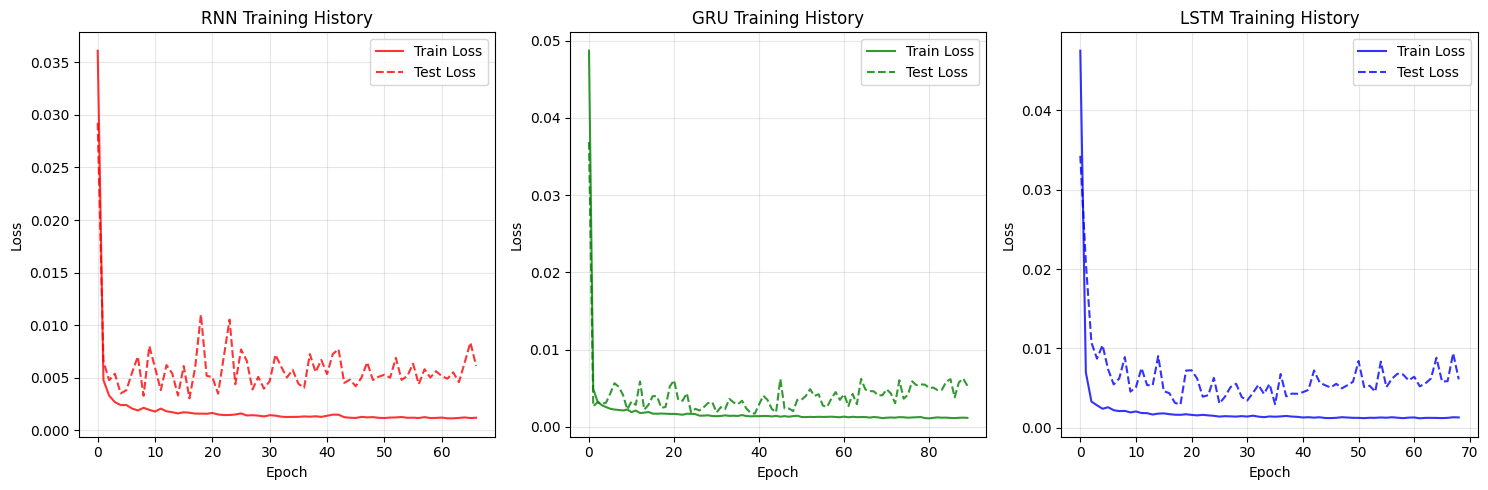


MODEL PERFORMANCE COMPARISON


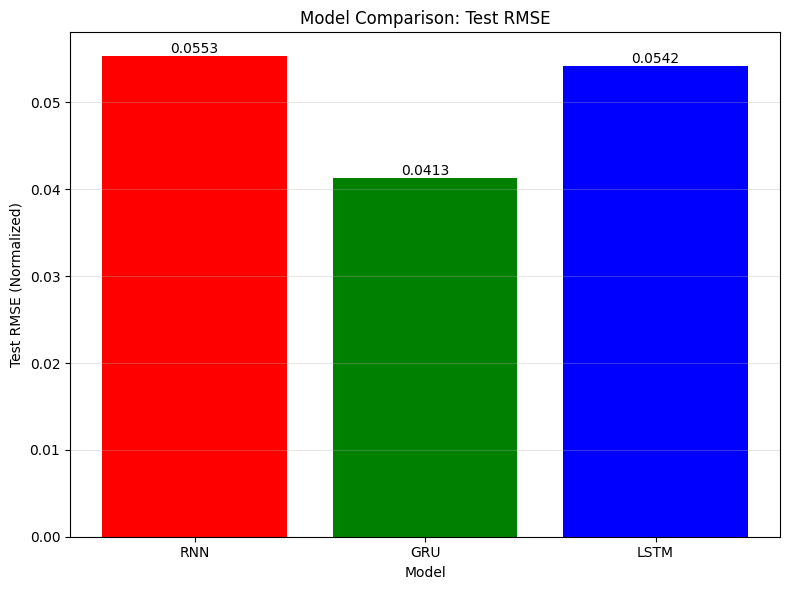

RNN: Test RMSE = 0.055304
GRU: Test RMSE = 0.041330
LSTM: Test RMSE = 0.054226

Best model: GRU (RMSE: 0.041330)


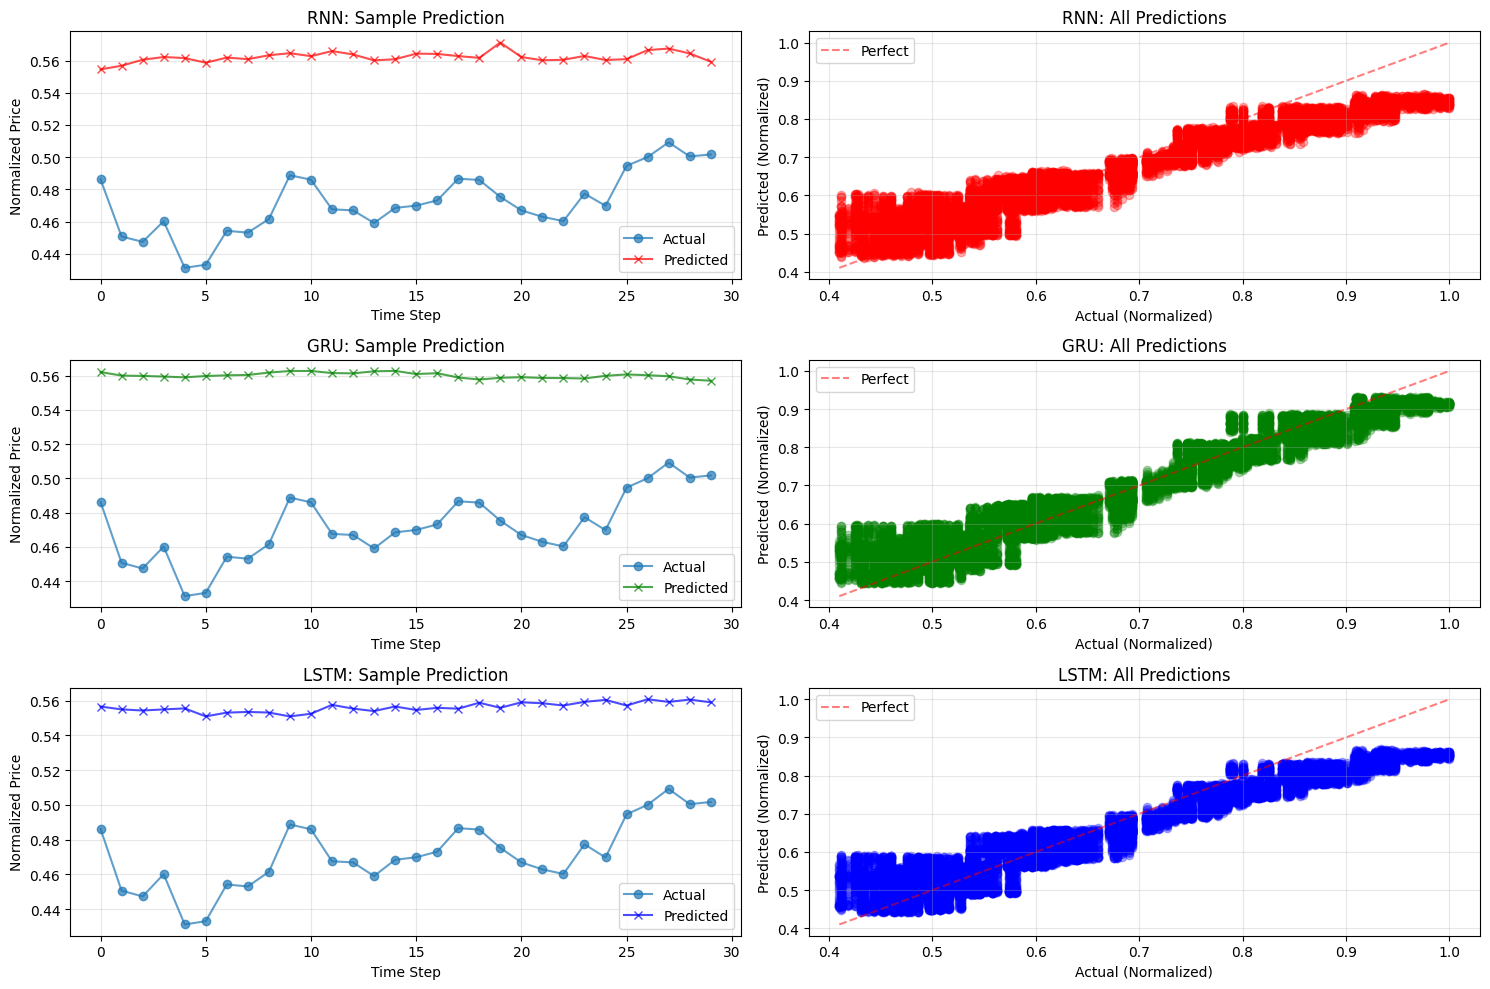

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# ============================================================================
# 1. RNN Model (Simple Recurrent Network)
# ============================================================================

class SimpleRNNModel(nn.Module):
    def __init__(self, input_len=60, output_len=30):
        super().__init__()
        self.input_len = input_len
        self.output_len = output_len
        
        # RNN layer
        self.rnn = nn.RNN(
            input_size=1, 
            hidden_size=50, 
            num_layers=2, 
            batch_first=True, 
            dropout=0.2,
            nonlinearity='tanh'
        )
        
        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Linear(50, 100),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(100, output_len)
        )
    
    def forward(self, x):
        # x shape: [batch_size, input_len, 1]
        rnn_out, hidden = self.rnn(x)
        last_hidden = hidden[-1]
        predictions = self.fc(last_hidden)
        return predictions.unsqueeze(-1)

# ============================================================================
# 2. GRU Model (Gated Recurrent Unit)
# ============================================================================

class SimpleGRUModel(nn.Module):
    def __init__(self, input_len=60, output_len=30):
        super().__init__()
        self.input_len = input_len
        self.output_len = output_len
        
        # GRU layer
        self.gru = nn.GRU(
            input_size=1, 
            hidden_size=50, 
            num_layers=2, 
            batch_first=True, 
            dropout=0.2
        )
        
        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Linear(50, 100),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(100, output_len)
        )
    
    def forward(self, x):
        # x shape: [batch_size, input_len, 1]
        gru_out, hidden = self.gru(x)
        last_hidden = hidden[-1]
        predictions = self.fc(last_hidden)
        return predictions.unsqueeze(-1)

# ============================================================================
# 3. LSTM Model (Your existing model)
# ============================================================================

class SimpleLSTMModel(nn.Module):
    def __init__(self, input_len=60, output_len=30):
        super().__init__()
        self.input_len = input_len
        self.output_len = output_len
        
        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=1, 
            hidden_size=50, 
            num_layers=2, 
            batch_first=True, 
            dropout=0.2
        )
        
        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Linear(50, 100),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(100, output_len)
        )
    
    def forward(self, x):
        # x shape: [batch_size, input_len, 1]
        lstm_out, (hidden, cell) = self.lstm(x)
        last_hidden = hidden[-1]
        predictions = self.fc(last_hidden)
        return predictions.unsqueeze(-1)

# ============================================================================
# 4. Training Function (Fixed version)
# ============================================================================

def train_model(model, model_name, X_train, y_train, X_test, y_test, 
                n_epochs=1000, lr=0.001, batch_size=32, patience=100):
    """
    Generic training function for RNN/LSTM/GRU models
    """
    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}")
    
    # Move to device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    model = model.to(device)
    X_train = X_train.float().to(device)
    y_train = y_train.float().to(device)
    X_test = X_test.float().to(device)
    y_test = y_test.float().to(device)
    
    # Optimizer
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # FIXED: Removed verbose parameter
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=patience//2, factor=0.5
    )
    
    # Loss function
    loss_fn = nn.MSELoss()
    
    # Data loader
    train_dataset = data.TensorDataset(X_train, y_train)
    loader = data.DataLoader(
        train_dataset, 
        shuffle=True, 
        batch_size=batch_size,
        drop_last=False
    )
    
    # Training tracking
    best_test_loss = float('inf')
    patience_counter = 0
    train_losses = []
    test_losses = []
    
    for epoch in range(n_epochs):
        # Training
        model.train()
        train_loss = 0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            train_loss += loss.item()
        
        avg_train_loss = train_loss / len(loader)
        train_losses.append(avg_train_loss)
        
        # Validation
        model.eval()
        with torch.no_grad():
            y_pred_test = model(X_test)
            test_loss = loss_fn(y_pred_test, y_test)
            test_rmse = torch.sqrt(test_loss)
            test_losses.append(test_loss.item())
        
        # Learning rate scheduling
        scheduler.step(test_loss)
        
        # Early stopping check
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            patience_counter = 0
            # Save best model
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': best_test_loss,
            }, f'best_{model_name.lower()}.pth')
        else:
            patience_counter += 1
        
        # Print progress
        if epoch % 100 == 0:
            with torch.no_grad():
                y_pred_train = model(X_train)
                train_rmse = torch.sqrt(loss_fn(y_pred_train, y_train))
            print(f"Epoch {epoch:4d}: Train RMSE: {train_rmse:.4f}, "
                  f"Test RMSE: {test_rmse:.4f}, "
                  f"LR: {optimizer.param_groups[0]['lr']:.6f}")
        
        # Early stopping
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
    
    # Load best model
    checkpoint = torch.load(f'best_{model_name.lower()}.pth', 
                           map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # Final evaluation
    model.eval()
    with torch.no_grad():
        y_pred_train = model(X_train)
        y_pred_test = model(X_test)
        
        train_rmse = torch.sqrt(loss_fn(y_pred_train, y_train)).item()
        test_rmse = torch.sqrt(loss_fn(y_pred_test, y_test)).item()
    
    print(f"\n{model_name} Final Results:")
    print(f"Train RMSE: {train_rmse:.6f}")
    print(f"Test RMSE:  {test_rmse:.6f}")
    
    return model, train_losses, test_losses, y_pred_test

# ============================================================================
# 5. Main Execution
# ============================================================================

def main():
    # Assuming df is already loaded
    print("Data shapes:")
    print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
    print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")
    
    # Define models to train
    models_to_train = {
        'RNN': SimpleRNNModel(input_len=60, output_len=30),
        'GRU': SimpleGRUModel(input_len=60, output_len=30),
        'LSTM': SimpleLSTMModel(input_len=60, output_len=30)
    }
    
    # Train all models
    results = {}
    for model_name, model in models_to_train.items():
        print(f"\nStarting training for {model_name}...")
        trained_model, train_losses, test_losses, y_pred_test = train_model(
            model=model,
            model_name=model_name,
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test=y_test,
            n_epochs=500,  # Reduced for testing
            lr=0.001,
            batch_size=32,
            patience=50
        )
        results[model_name] = (trained_model, train_losses, test_losses, y_pred_test)
    
    # Plot training curves
    plt.figure(figsize=(15, 5))
    
    colors = {'RNN': 'red', 'GRU': 'green', 'LSTM': 'blue'}
    
    for idx, (model_name, (_, train_losses, test_losses, _)) in enumerate(results.items()):
        plt.subplot(1, 3, idx+1)
        plt.plot(train_losses, label='Train Loss', color=colors[model_name], alpha=0.8)
        plt.plot(test_losses, label='Test Loss', color=colors[model_name], 
                linestyle='--', alpha=0.8)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title(f'{model_name} Training History')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Compare test RMSE
    print(f"\n{'='*60}")
    print("MODEL PERFORMANCE COMPARISON")
    print(f"{'='*60}")
    
    loss_fn = nn.MSELoss()
    test_rmses = {}
    
    for model_name, (_, _, _, y_pred_test) in results.items():
        with torch.no_grad():
            test_loss = loss_fn(y_pred_test, y_test)
            test_rmse = torch.sqrt(test_loss).item()
            test_rmses[model_name] = test_rmse
    
    # Plot bar chart
    plt.figure(figsize=(8, 6))
    bars = plt.bar(test_rmses.keys(), test_rmses.values(), 
                   color=[colors[name] for name in test_rmses.keys()])
    plt.xlabel('Model')
    plt.ylabel('Test RMSE (Normalized)')
    plt.title('Model Comparison: Test RMSE')
    plt.grid(True, alpha=0.3, axis='y')
    
    # Add values on bars
    for bar, (model_name, rmse) in zip(bars, test_rmses.items()):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{rmse:.4f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Print results
    for model_name, rmse in test_rmses.items():
        print(f"{model_name}: Test RMSE = {rmse:.6f}")
    
    # Best model
    best_model_name = min(test_rmses, key=test_rmses.get)
    print(f"\nBest model: {best_model_name} (RMSE: {test_rmses[best_model_name]:.6f})")
    
    # Plot sample predictions from each model
    plt.figure(figsize=(15, 10))
    
    for idx, (model_name, (_, _, _, y_pred_test)) in enumerate(results.items()):
        plt.subplot(3, 2, 2*idx+1)
        
        # Sample prediction
        sample_idx = 0
        actual = y_test[sample_idx, :, 0].cpu().numpy()
        predicted = y_pred_test[sample_idx, :, 0].cpu().numpy()
        
        plt.plot(actual, label='Actual', marker='o', alpha=0.7)
        plt.plot(predicted, label='Predicted', marker='x', 
                color=colors[model_name], alpha=0.7)
        plt.xlabel('Time Step')
        plt.ylabel('Normalized Price')
        plt.title(f'{model_name}: Sample Prediction')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Scatter plot for all predictions
        plt.subplot(3, 2, 2*idx+2)
        
        all_actual = y_test[:, :, 0].cpu().numpy().flatten()
        all_pred = y_pred_test[:, :, 0].cpu().numpy().flatten()
        
        plt.scatter(all_actual, all_pred, alpha=0.3, color=colors[model_name])
        
        # Perfect prediction line
        min_val = min(all_actual.min(), all_pred.min())
        max_val = max(all_actual.max(), all_pred.max())
        plt.plot([min_val, max_val], [min_val, max_val], 
                'r--', alpha=0.5, label='Perfect')
        
        plt.xlabel('Actual (Normalized)')
        plt.ylabel('Predicted (Normalized)')
        plt.title(f'{model_name}: All Predictions')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# 6. Run the training
# ============================================================================

# Make sure you have your data ready
if __name__ == "__main__":
    # Load your data
    # df = pd.read_csv('your_data.csv')
    
    # Prepare data (assuming you already have this part)
    # X_train, y_train, X_test, y_test should be defined
    
    print("Starting model training...")
    main()